**Phase 1: Environment & Data Pipeline**


**Cell 1: Environment Setup & Library Imports**

This cell handles the foundation of our project. We'll import the core PyTorch libraries, set up the T4 x2 Dual GPU configuration using DataParallel for simplicity in a notebook environment, and ensure we have the necessary tools for Mixed Precision training to optimize memory on the Kaggle T4s.

In [23]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# For Mixed Precision Training
from torch.cuda.amp import GradScaler, autocast

# For evaluation metrics
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# 1. Device Configuration (Dual GPU T4 Setup)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()

print(f"Using device: {device}")
if num_gpus > 1:
    print(f"Dual GPU Detected! Count: {num_gpus}")
else:
    print("Only 1 GPU detected. Ensure T4 x2 is enabled in Kaggle settings.")

# 2. Hyperparameters from Assignment Manual
IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # (224/16)^2 = 196
MASK_RATIO = 0.75
KEEP_COUNT = int(NUM_PATCHES * (1 - MASK_RATIO)) # 49 patches visible

# Encoder Config (ViT-Base)
ENC_EMBED_DIM = 768
ENC_DEPTH = 12
ENC_HEADS = 12

# Decoder Config (ViT-Small)
DEC_EMBED_DIM = 384
DEC_DEPTH = 12
DEC_HEADS = 6

# Training Config
BATCH_SIZE = 64 # Adjusted for T4 x2
LEARNING_RATE = 1.5e-4
WEIGHT_DECAY = 0.05
EPOCHS = 30 # Adjust based on your available Kaggle time

print(f"Environment initialized. Patch count: {NUM_PATCHES}, Visible: {KEEP_COUNT}")

Using device: cuda
Dual GPU Detected! Count: 2
Environment initialized. Patch count: 196, Visible: 49


**Cell 2: Dataset Integration (TinyImageNet)**

In this cell, we set up the data pipeline. Since TinyImageNet images are originally $64 \times 64$, we must resize them to $224 \times 224$ to match the ViT-Base requirements specified in your manual. We also include standard normalization for ImageNet.

In [24]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

print(" Initializing TinyImageNet dataset loader...")

# 1. Dataset Path
DATASET_PATH = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"
print(f" Dataset path set to: {DATASET_PATH}")

# 2. Define Transformations
print(" Preparing image transformations...")

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print(" Transformations ready")

# 3. Load Training Dataset
print(" Loading training dataset (this may take ~20-60 seconds)...")

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'train'),
    transform=transform_train
)

print(f" Training dataset loaded")
print(f"   • Classes found: {len(train_dataset.classes)}")
print(f"   • Total training images: {len(train_dataset)}")

# 4. Create Validation Subset
print(" Creating validation subset (500 images)...")

val_dataset = Subset(train_dataset, torch.arange(500))

print(f" Validation subset ready")
print(f"   • Validation images: {len(val_dataset)}")

# 5. Create DataLoaders
print(" Building DataLoaders...")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(" DataLoaders created successfully!")

print("\n Dataset Summary")
print("----------------------")
print(f"Training Images : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Image Size : {IMG_SIZE}x{IMG_SIZE}")

 Initializing TinyImageNet dataset loader...
 Dataset path set to: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
 Preparing image transformations...
 Transformations ready
 Loading training dataset (this may take ~20-60 seconds)...
 Training dataset loaded
   • Classes found: 200
   • Total training images: 100000
 Creating validation subset (500 images)...
 Validation subset ready
   • Validation images: 500
 Building DataLoaders...
 DataLoaders created successfully!

 Dataset Summary
----------------------
Training Images : 100000
Validation Images : 500
Batch Size : 64
Image Size : 224x224


**Cell 3: Patchification Utility**

This cell contains the helper functions to convert a standard image tensor into a sequence of patches and vice versa. This is crucial for the Transformer to process the visual data as a sequence of tokens.

In [25]:
def patchify(imgs):
    """
    imgs: (N, 3, H, W)
    x: (N, L, patch_size**2 * 3)
    """
    p = PATCH_SIZE
    assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0

    h = w = imgs.shape[2] // p
    x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
    x = torch.einsum('nchpwq->nhwpqc', x)
    x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
    return x

def unpatchify(x):
    """
    x: (N, L, patch_size**2 * 3)
    imgs: (N, 3, H, W)
    """
    p = PATCH_SIZE
    h = w = int(x.shape[1]**.5)
    assert h * w == x.shape[1]
    
    x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
    x = torch.einsum('nhwpqc->nchpwq', x)
    imgs = x.reshape(shape=(x.shape[0], 3, h * p, w * p))
    return imgs

# Quick Verification
sample_batch, _ = next(iter(train_loader))
patches = patchify(sample_batch)
reconstructed_check = unpatchify(patches)

print(f"Original shape: {sample_batch.shape}")
print(f"Patched shape: {patches.shape}")
print(f"Unpatched shape: {reconstructed_check.shape}")

Original shape: torch.Size([64, 3, 224, 224])
Patched shape: torch.Size([64, 196, 768])
Unpatched shape: torch.Size([64, 3, 224, 224])


**Phase 2: Core Architecture Development**

**Cell 4: Random Masking Module**

This is the core logic of the MAE. We need to randomly shuffle the patches, keep the first 25% for the encoder, and keep track of the original indices so the decoder can put them back in the correct order.

In [26]:
def random_masking(x, mask_ratio):
    """
    Perform per-sample random masking by shuffling.
    Per-sample shuffling is done by argsort random noise.
    x: [N, L, D], sequence
    """
    N, L, D = x.shape  # batch, length, dim
    len_keep = int(L * (1 - mask_ratio))
    
    # Generate random noise for each patch in each image
    noise = torch.rand(N, L, device=x.device)  # noise in [0, 1]
    
    # Sort noise for each sample:
    # ids_shuffle: indices that would sort the noise (random order)
    # ids_restore: indices that would restore the original order
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # Keep the first len_keep indices
    ids_keep = ids_shuffle[:, :len_keep]
    
    # Extract the patches to keep (Visible Patches)
    # x_masked has shape [N, len_keep, D]
    x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

    # Generate the binary mask: 0 is keep, 1 is remove
    mask = torch.ones([N, L], device=x.device)
    mask[:, :len_keep] = 0
    # Unshuffle to get the binary mask in original patch order
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_masked, mask, ids_restore

# Verification Block
# Generating dummy data: 1 image, 196 patches, 768 embedding dimension
x_sample = torch.randn(1, 196, 768).to(device)
x_masked, mask, ids_restore = random_masking(x_sample, 0.75)

print(f"Input Shape: {x_sample.shape}")
print(f"Masked Shape (Visible only): {x_masked.shape}")
print(f"Mask Shape: {mask.shape}")
print(f"Restore Indices Shape: {ids_restore.shape}")

Input Shape: torch.Size([1, 196, 768])
Masked Shape (Visible only): torch.Size([1, 49, 768])
Mask Shape: torch.Size([1, 196])
Restore Indices Shape: torch.Size([1, 196])


**Cell 5: The Encoder (ViT-Base)**

The encoder is a ViT-Base model. According to your requirements, it must process only the visible patches (25%). It includes a patch embedding layer, adds positional embeddings, and passes the tokens through 12 Transformer layers. Crucially, we do not include mask tokens here to maintain the efficiency of the MAE architecture.

In [27]:
class Encoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.):
        super().__init__()

        # 1. Patch Embedding
        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2

        # 2. Positional Embedding (Learnable)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        # 3. Transformer Layers
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                dropout=0.1,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.initialize_weights()

    def initialize_weights(self):
        torch.nn.init.normal_(self.pos_embed, std=.02)

    def forward(self, x, mask_ratio=0.75):
        # Patchify and Embed: (N, 3, 224, 224) -> (N, 768, 14, 14) -> (N, 196, 768)
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        # Add Positional Embedding
        x = x + self.pos_embed

        # Masking: Retain only 25% of the patches
        x_visible, mask, ids_restore = random_masking(x, mask_ratio)

        # Pass through Transformer Blocks
        for block in self.blocks:
            x_visible = block(x_visible)
            
        x_visible = self.norm(x_visible)

        return x_visible, mask, ids_restore

# Verification Block
encoder_test = Encoder().to(device)
sample_img = torch.randn(1, 3, 224, 224).to(device)
latent, mask, ids_restore = encoder_test(sample_img)

print(f"Encoder Input: {sample_img.shape}")
print(f"Latent Representation (Visible Only): {latent.shape}")
print(f"Mask Shape: {mask.shape}")

Encoder Input: torch.Size([1, 3, 224, 224])
Latent Representation (Visible Only): torch.Size([1, 49, 768])
Mask Shape: torch.Size([1, 196])


**Cell 6: The Decoder (ViT-Small)**

The decoder is a ViT-Small model. Its job is to take the latent representations of the visible patches, combine them with learnable mask tokens for the missing patches, and reconstruct the original pixels.As per your requirements:Linear Projection: Projects encoder dimension (768) to decoder dimension (384).Positional Embeddings: Added to all tokens (visible + mask) so the model knows where each patch belongs in the 2D grid.Output Layer: A linear layer that projects the 384 dimensions back to $16 \times 16 \times 3 = 768$ (pixel values for the patch).

In [28]:
class Decoder(nn.Module):
    def __init__(self, num_patches=196, enc_embed_dim=768, 
                 dec_embed_dim=384, depth=12, num_heads=6, mlp_ratio=4.):
        super().__init__()

        # 1. Project Encoder tokens to Decoder dimension
        self.decoder_embed = nn.Linear(enc_embed_dim, dec_embed_dim, bias=True)

        # 2. Learnable Mask Token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_embed_dim))

        # 3. Decoder Positional Embeddings
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches, dec_embed_dim))

        # 4. Decoder Transformer Layers (ViT-Small)
        self.decoder_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=dec_embed_dim,
                nhead=num_heads,
                dim_feedforward=int(dec_embed_dim * mlp_ratio),
                dropout=0.1,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(depth)
        ])

        self.decoder_norm = nn.LayerNorm(dec_embed_dim)
        
        # 5. Predictor: Linear layer to reconstruct pixel values
        self.decoder_pred = nn.Linear(dec_embed_dim, PATCH_SIZE**2 * 3, bias=True)

        self.initialize_weights()

    def initialize_weights(self):
        torch.nn.init.normal_(self.decoder_pos_embed, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)

    def forward(self, x, ids_restore):
        # Project to decoder dimension
        x = self.decoder_embed(x)

        # Append mask tokens to sequence
        # mask_tokens: [N, L - len_keep, D]
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] - x.shape[1], 1)
        
        # Concatenate visible and mask tokens
        x_ = torch.cat([x, mask_tokens], dim=1)  # no shuffle yet
        
        # Unshuffle: Put everything back in original order using ids_restore
        x = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))

        # Add decoder positional embeddings
        x = x + self.decoder_pos_embed

        # Pass through decoder transformer blocks
        for block in self.decoder_blocks:
            x = block(x)
            
        x = self.decoder_norm(x)

        # Predict pixel values
        x = self.decoder_pred(x)

        return x

# Verification Block
decoder_test = Decoder().to(device)
# dummy latent from previous cell verification: [1, 49, 768]
# ids_restore: [1, 196]
reconstructed_patches = decoder_test(latent, ids_restore)

print(f"Decoder Input (Latent): {latent.shape}")
print(f"Decoder Output (Reconstructed Patches): {reconstructed_patches.shape}")

Decoder Input (Latent): torch.Size([1, 49, 768])
Decoder Output (Reconstructed Patches): torch.Size([1, 196, 768])


**Cell 7: The MAE Model Wrapper**

This cell integrates the Encoder and Decoder into a single cohesive class. This wrapper handles the full pipeline: patchifying the input image, passing it through the encoder, using the decoder to reconstruct the missing patches, and providing the necessary variables (like the binary mask) for loss calculation.

In [29]:
class MaskedAutoencoder(nn.Module):
    def __init__(self, 
                 img_size=224, 
                 patch_size=16, 
                 in_chans=3,
                 embed_dim=768, 
                 enc_depth=12, 
                 enc_heads=12,
                 dec_embed_dim=384, 
                 dec_depth=12, 
                 dec_heads=6,
                 mlp_ratio=4.):
        super().__init__()

        # 1. Encoder (ViT-Base)
        self.encoder = Encoder(
            img_size=img_size, 
            patch_size=patch_size, 
            in_chans=in_chans,
            embed_dim=embed_dim, 
            depth=enc_depth, 
            num_heads=enc_heads, 
            mlp_ratio=mlp_ratio
        )

        # 2. Decoder (ViT-Small)
        num_patches = (img_size // patch_size) ** 2
        self.decoder = Decoder(
            num_patches=num_patches, 
            enc_embed_dim=embed_dim, 
            dec_embed_dim=dec_embed_dim, 
            depth=dec_depth, 
            num_heads=dec_heads, 
            mlp_ratio=mlp_ratio
        )

    def forward(self, imgs, mask_ratio=0.75):
        # Step 1: Encoder pass (includes internal random masking)
        # latent: [N, L_visible, D_enc], mask: [N, L], ids_restore: [N, L]
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)

        # Step 2: Decoder pass
        # pred: [N, L, patch_size**2 * 3]
        pred = self.decoder(latent, ids_restore)

        return pred, mask

# Initialize the full model
model = MaskedAutoencoder().to(device)

# Multi-GPU support (T4 x2)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    print(f"Model wrapped in DataParallel across {torch.cuda.device_count()} GPUs")

# Verification
test_img = torch.randn(1, 3, 224, 224).to(device)
prediction, mask_out = model(test_img)

print(f"Input Image: {test_img.shape}")
print(f"Prediction Patches: {prediction.shape}")
print(f"Mask Shape: {mask_out.shape}")

Model wrapped in DataParallel across 2 GPUs
Input Image: torch.Size([1, 3, 224, 224])
Prediction Patches: torch.Size([1, 196, 768])
Mask Shape: torch.Size([1, 196])


**Cell 8: Custom Loss Function (MSE on Masked Patches)**

According to the assignment requirements, the loss must only be computed on the masked patches. Calculating loss on visible patches is unnecessary because the model already "sees" them. We use the binary mask (where 1 represents a masked patch and 0 represents a visible one) to isolate these regions.We first convert the original images into patches to create a ground truth target, then use the binary mask to zero out the loss from visible patches.

In [30]:
def mae_loss_func(imgs, pred, mask):
    """
    imgs: [N, 3, 224, 224]
    pred: [N, 196, 768] - Reconstructed patches
    mask: [N, 196] - 0 for visible, 1 for masked
    """
    # 1. Patchify the original images to get ground truth patches (N, 196, 768)
    target = patchify(imgs)
    
    # 2. Compute Mean Squared Error per patch
    # (pred - target)^2 results in [N, 196, 768]
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)  # [N, 196], mean loss per patch

    # 3. Apply mask to ignore visible patches
    # We multiply by the mask (1 for masked, 0 for visible)
    # Then divide by the number of masked patches to get the average
    masked_loss = (loss * mask).sum() / mask.sum() 
    
    return masked_loss

# Verification Block
model.eval()
with torch.no_grad():
    # Use the test_img and prediction from Cell 7
    sample_loss = mae_loss_func(test_img, prediction, mask_out)
    
    print(f"Input Image Shape: {test_img.shape}")
    print(f"Prediction Shape: {prediction.shape}")
    print(f"Mask Shape: {mask_out.shape}")
    print(f"Computed MSE Loss (Masked Patches Only): {sample_loss.item():.6f}")

# Reset model to train mode
model.train()

Input Image Shape: torch.Size([1, 3, 224, 224])
Prediction Shape: torch.Size([1, 196, 768])
Mask Shape: torch.Size([1, 196])
Computed MSE Loss (Masked Patches Only): 1.338115


DataParallel(
  (module): MaskedAutoencoder(
    (encoder): Encoder(
      (patch_embed): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (blocks): ModuleList(
        (0-11): 12 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (linear1): Linear(in_features=768, out_features=3072, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=3072, out_features=768, bias=True)
          (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): Decoder(
      (decoder_embed): Linear(in_features=768, out_feature

**Cell 9: Optimizer and Scheduler Setup**

This cell initializes the AdamW optimizer with the specific weight decay from your manual and sets up the Cosine Annealing scheduler for the learning rate. It also prepares the GradScaler for Mixed Precision training.

In [31]:
import torch.optim as optim

# 1. Optimizer: AdamW with weight decay (0.05) as per manual
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    betas=(0.9, 0.95), 
    weight_decay=WEIGHT_DECAY
)

# 2. Scheduler: Cosine Annealing LR
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=EPOCHS, 
    eta_min=1e-6
)

# 3. Mixed Precision Scaler (Modern torch.amp API)
scaler = torch.amp.GradScaler('cuda')

print("Optimizer, Scheduler, and updated GradScaler initialized.")

Optimizer, Scheduler, and updated GradScaler initialized.


**Cell 10: The Training Loop**

This cell implements the full training process for the Masked Autoencoder. It integrates Automatic Mixed Precision (AMP) to optimize memory usage on the T4 GPUs and uses the AdamW optimizer with the Cosine Annealing scheduler. The loss is recorded per epoch to facilitate the training logs required for your deliverables.

In [33]:
import torch.nn.utils as utils
import time

# 1. Initialize two lists to track both losses
train_loss_history = []
val_loss_history = []

print(f"Starting Training for {EPOCHS} epochs on {device}...")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    start_time = time.time()

    for batch_idx, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred, mask = model(imgs)
            loss = mae_loss_func(imgs, pred, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # --- VALIDATION PHASE (Added) ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for val_imgs, _ in val_loader:
            val_imgs = val_imgs.to(device)
            with torch.amp.autocast('cuda'):
                val_pred, val_mask = model(val_imgs)
                v_loss = mae_loss_func(val_imgs, val_pred, val_mask)
            total_val_loss += v_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    scheduler.step()
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Time: {time.time()-start_time:.2f}s")

print("Training process complete.")

Starting Training for 30 epochs on cuda...
Epoch 1/30 | Train Loss: 0.802191 | Val Loss: 0.570017 | Time: 562.45s
Epoch 2/30 | Train Loss: 0.601115 | Val Loss: 0.373797 | Time: 559.98s
Epoch 3/30 | Train Loss: 0.447977 | Val Loss: 0.254578 | Time: 559.95s
Epoch 4/30 | Train Loss: 0.378302 | Val Loss: 0.213274 | Time: 560.78s
Epoch 5/30 | Train Loss: 0.339727 | Val Loss: 0.190298 | Time: 560.95s
Epoch 6/30 | Train Loss: 0.317548 | Val Loss: 0.194371 | Time: 561.22s
Epoch 7/30 | Train Loss: 0.302347 | Val Loss: 0.175427 | Time: 560.92s
Epoch 8/30 | Train Loss: 0.291478 | Val Loss: 0.163559 | Time: 560.42s
Epoch 9/30 | Train Loss: 0.282609 | Val Loss: 0.161482 | Time: 559.45s
Epoch 10/30 | Train Loss: 0.275216 | Val Loss: 0.159450 | Time: 559.55s
Epoch 11/30 | Train Loss: 0.269152 | Val Loss: 0.152483 | Time: 559.26s
Epoch 12/30 | Train Loss: 0.263901 | Val Loss: 0.151608 | Time: 559.41s
Epoch 13/30 | Train Loss: 0.259759 | Val Loss: 0.145366 | Time: 558.92s
Epoch 14/30 | Train Loss: 0.25

**Cell 10.5: Saving and Loading the Model**

This cell allows you to save your progress. In Kaggle, files saved to /kaggle/working/ can be downloaded to your local computer.

In [1]:
# 1. Save the Model (Corrected Indentation and Arguments)
def save_checkpoint(model, optimizer, scheduler, epoch, train_hist, val_hist, filename="mae_checkpoint.pth"):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss_history': train_hist, 
        'val_loss_history': val_hist     
    }
    torch.save(checkpoint, filename)
    print(f" Checkpoint saved to {filename} at Epoch {epoch}")

# 2. Usage (Run this ONLY AFTER the 30-epoch training finishes)
# Make sure these variable names match what you used in your training loop!
save_checkpoint(
    model, 
    optimizer, 
    scheduler, 
    EPOCHS, 
    train_loss_history, 
    val_loss_history
)

 Checkpoint saved to mae_checkpoint.pth at Epoch 30


**Phase 4: Visualization & Metrics**

**Cell 11: Reconstruction Visualization Utility**

This cell addresses the requirement to show: Masked Input (75% removed), Model Reconstruction, and Original Ground Truth. It processes 5 qualitative examples from the validation set.

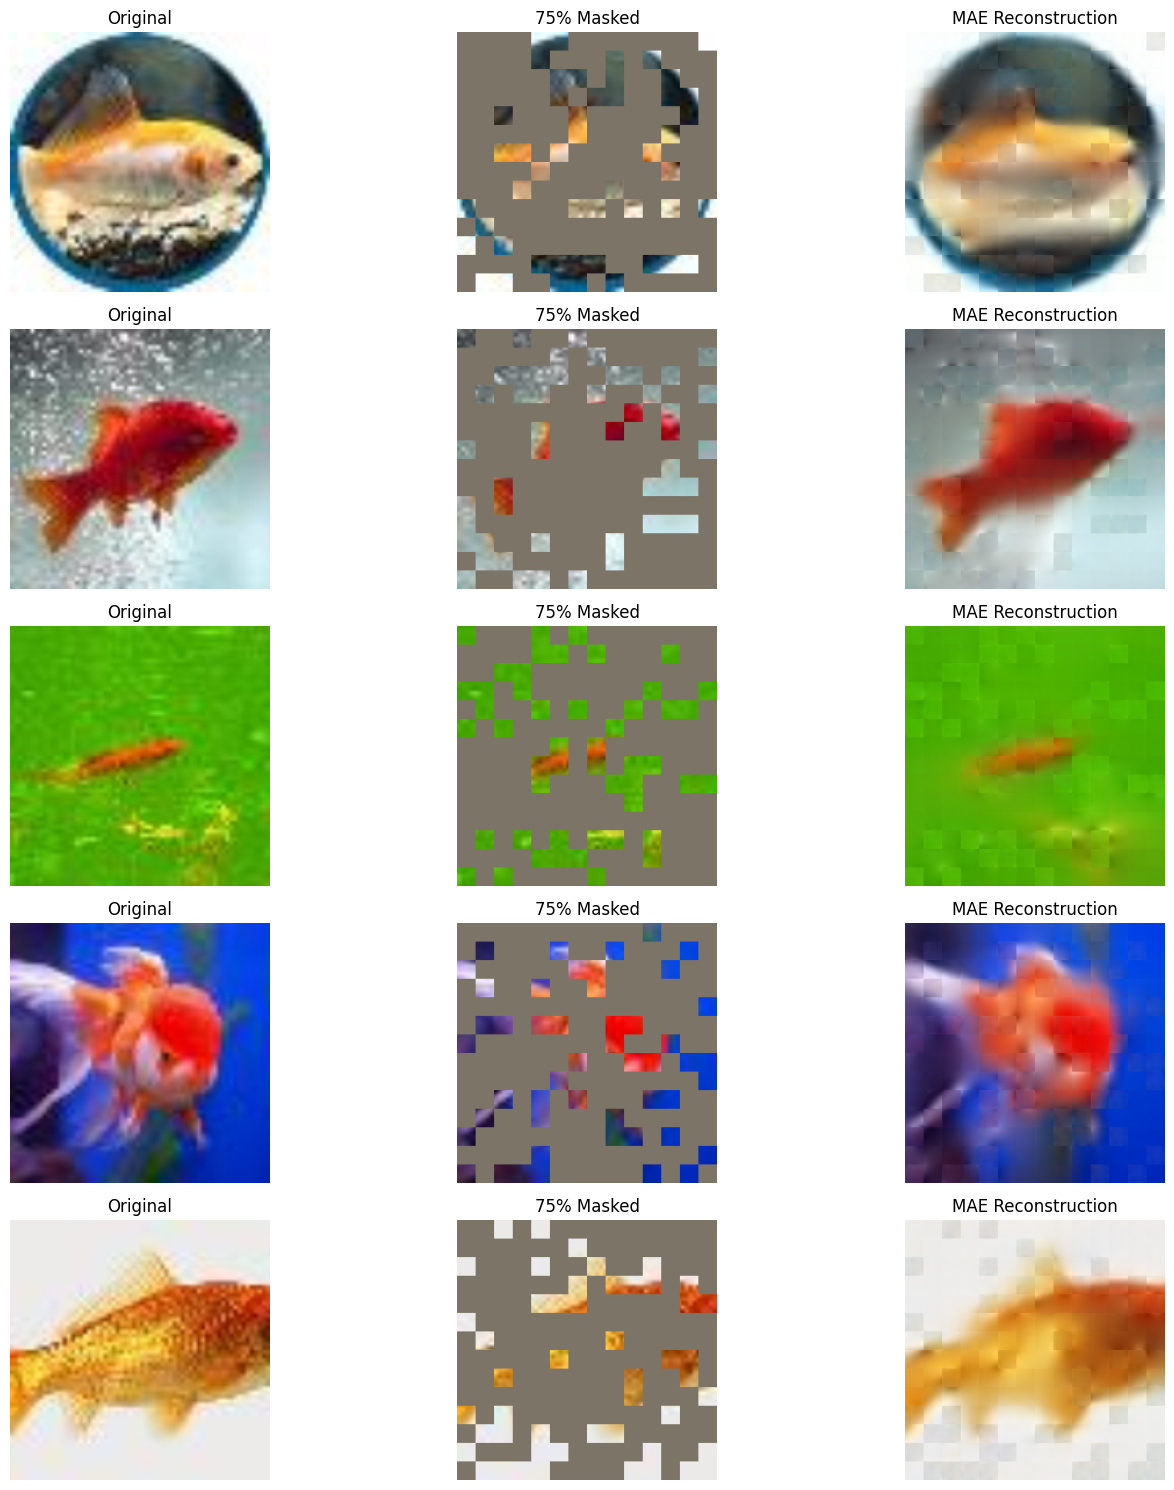

In [13]:
def visualize_reconstruction(model, dataset, num_samples=5):
    model.eval()
    samples, _ = next(iter(DataLoader(dataset, batch_size=num_samples, shuffle=True)))
    samples = samples.to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            # Forward pass
            pred, mask = model(samples)
            
            # Unpatchify the prediction
            reconstructed_imgs = unpatchify(pred)
            
            # Create the masked image for visualization
            # 1. Patchify original
            original_patches = patchify(samples)
            # 2. Apply mask (0 for keep, 1 for remove)
            # We multiply by (1 - mask) to keep 25% and make the rest black
            masked_patches = original_patches * (1 - mask.unsqueeze(-1))
            # 3. Unpatchify back to image space
            masked_imgs = unpatchify(masked_patches)

    # Denormalize images for plotting
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    
    samples = (samples * std + mean).cpu().clamp(0, 1)
    masked_imgs = (masked_imgs * std + mean).cpu().clamp(0, 1)
    reconstructed_imgs = (reconstructed_imgs * std + mean).cpu().clamp(0, 1)

    # Plotting
    plt.figure(figsize=(15, num_samples * 3))
    for i in range(num_samples):
        # Ground Truth
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(samples[i].permute(1, 2, 0))
        plt.title("Original")
        plt.axis('off')

        # Masked Input
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masked_imgs[i].permute(1, 2, 0))
        plt.title("75% Masked")
        plt.axis('off')

        # Reconstruction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(reconstructed_imgs[i].permute(1, 2, 0))
        plt.title("MAE Reconstruction")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_reconstruction(model, val_dataset)

**Cell 12: Quantitative Evaluation (PSNR & SSIM)**

This cell handles the quantitative assessment of the model's performance. As required by your assignment, we calculate the Peak Signal-to-Noise Ratio (PSNR) and the Structural Similarity Index (SSIM). These metrics compare the original image to the reconstructed version to measure quality and structural fidelity.

In [5]:
def calculate_metrics(model, dataloader):
    model.eval()
    psnr_values = []
    ssim_values = []
    
    # Denormalization parameters
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    print("Calculating PSNR and SSIM on validation set...")
    
    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                pred, _ = model(imgs)
                recon = unpatchify(pred)
            
            # Convert to numpy and denormalize
            imgs_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
            recon_np = recon.cpu().permute(0, 2, 3, 1).numpy()
            
            # Rescale to [0, 1]
            imgs_np = np.clip(imgs_np * std + mean, 0, 1)
            recon_np = np.clip(recon_np * std + mean, 0, 1)

            for i in range(imgs_np.shape[0]):
                # PSNR
                p = psnr(imgs_np[i], recon_np[i], data_range=1.0)
                psnr_values.append(p)
                
                # SSIM (Multichannel must be specified for RGB)
                s = ssim(imgs_np[i], recon_np[i], data_range=1.0, channel_axis=-1)
                ssim_values.append(s)
                
            # We only need a subset for the report to save time
            if len(psnr_values) >= 100: 
                break

    avg_psnr = np.mean(psnr_values)
    avg_ssim = np.mean(ssim_values)
    
    print("-" * 30)
    print(f"Mean PSNR: {avg_psnr:.2f} dB")
    print(f"Mean SSIM: {avg_ssim:.4f}")
    print("-" * 30)
    
    return avg_psnr, avg_ssim

# Run evaluation
avg_psnr, avg_ssim = calculate_metrics(model, val_loader)

Calculating PSNR and SSIM on validation set...
------------------------------
Mean PSNR: 23.41 dB
Mean SSIM: 0.6783
------------------------------


**Cell 13: Training Logs Plot**

To fulfill the deliverable requirement for training logs, this cell plots the reconstruction loss (MSE) across all epochs. A downward trend indicates that the model is successfully learning the underlying visual patterns.

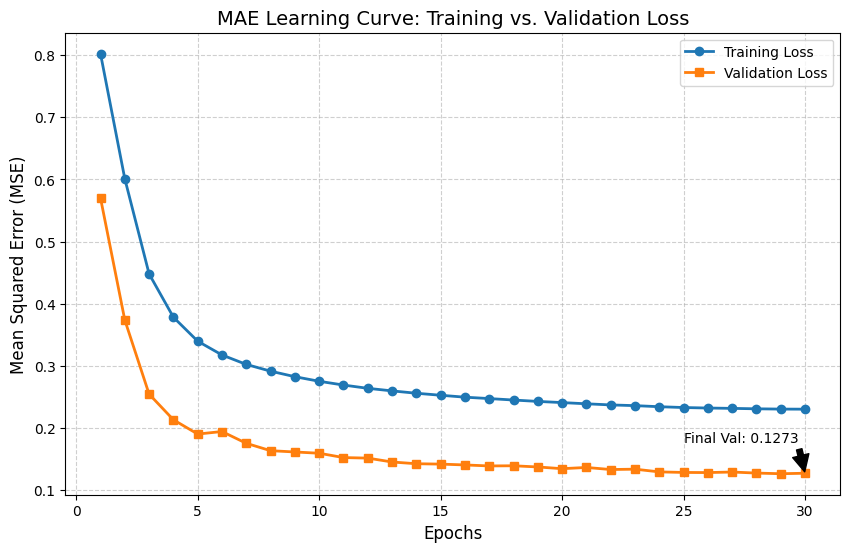

In [8]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_hist, val_hist):
    plt.figure(figsize=(10, 6))
    
    # Plot Training Loss
    plt.plot(range(1, len(train_hist) + 1), train_hist, 
             label='Training Loss', color='#1f77b4', marker='o', linewidth=2)
    
    # Plot Validation Loss
    plt.plot(range(1, len(val_hist) + 1), val_hist, 
             label='Validation Loss', color='#ff7f0e', marker='s', linewidth=2)
    
    plt.title("MAE Learning Curve: Training vs. Validation Loss", fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Highlight the final values
    if len(val_hist) > 0:
        plt.annotate(f'Final Val: {val_hist[-1]:.4f}', 
                     xy=(len(val_hist), val_hist[-1]), 
                     xytext=(len(val_hist)-5, val_hist[-1]+0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.show()

# Run the updated plotting logic
if len(train_loss_history) > 0:
    plot_learning_curves(train_loss_history, val_loss_history)
else:
    print(" Training hasn't finished yet! Wait for the 30 epochs to complete.")

**Cell 14: App Deployment (Gradio Interface)**

This final cell builds the Gradio application required by your manual. It allows users to upload an image, adjust the masking ratio via a slider, and see the model's reconstruction in real-time.

To run this in Kaggle, you may need to install the library first by running !pip install gradio in a separate cell if it's not already available.

In [9]:
import gradio as gr
import torch
import numpy as np
from PIL import Image

def mae_reconstruct(input_img, mask_ratio):
    if input_img is None:
        return None, None
        
    # 1. Preprocess the input image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Add batch dimension and move to device
    img_tensor = transform(input_img).unsqueeze(0).to(device)
    
    # 2. Model Inference
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            # Explicitly passing arguments as keywords to fix DataParallel TypeError
            # We use 'imgs' because that is the name of the first argument in our forward()
            pred, mask = model(imgs=img_tensor, mask_ratio=mask_ratio)
            
            # Reconstruction logic
            recon_img = unpatchify(pred)
            
            # Create masked version for display
            patches = patchify(img_tensor)
            # mask is [1, 196], we need [1, 196, 1] for multiplication
            masked_patches = patches * (1 - mask.unsqueeze(-1))
            masked_img = unpatchify(masked_patches)
    
    # 3. Post-process for visualization (Denormalization)
    def denormalize(tensor):
        # Move mean/std to same device as tensor
        m = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(tensor.device)
        s = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(tensor.device)
        tensor = (tensor * s + m).cpu().clamp(0, 1)
        return tensor.squeeze(0).permute(1, 2, 0).numpy()

    final_masked = denormalize(masked_img)
    final_recon = denormalize(recon_img)
    
    # Convert to 8-bit integers for Gradio display
    return (final_masked * 255).astype(np.uint8), (final_recon * 255).astype(np.uint8)

# Define Gradio Interface
demo = gr.Interface(
    fn=mae_reconstruct,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(minimum=0.1, maximum=0.9, value=0.75, step=0.05, label="Masking Ratio")
    ],
    outputs=[
        gr.Image(label="Masked Input (Only 25% Visible)"),
        gr.Image(label="MAE Reconstruction")
    ],
    title="Self-Supervised Masked Autoencoder (MAE)",
    description="This app demonstrates visual representation learning. The model only sees the unmasked patches and attempts to reconstruct the missing 75% of the image."
)

# Launch the app
# share=True provides a temporary public link which is useful in Kaggle
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0c4e567450ea5550bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
